In [1]:
import pandas as pd
import numpy as np


# ============================================================
# LOAD COUNT MATRIX
# ============================================================

counts = pd.read_csv(
    "../data/processed/CPTAC_GBM_GTEx_7_combined_raw_counts.csv",
    index_col=0
)

counts = counts.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)


# ============================================================
# LOAD CPTAC SUBTYPE METADATA
# ============================================================

subtypes = pd.read_csv(
    "../data/raw/all_subtypes.v5.1.tsv",
    sep="\t",
    dtype=str
)

subtypes = subtypes.rename(
    columns={
        subtypes.columns[0]: "case_id",
        "rna_wang_cancer_cell_2017": "subtype"
    }
)

subtypes["case_id"] = (
    subtypes["case_id"]
    .astype(str)
    .str.strip()
)

cptac_cases = (
    subtypes["case_id"]
    .dropna()
    .unique()
)


# ============================================================
# LOAD GDC SAMPLE SHEET
# ============================================================

gdc_sheet = pd.read_csv(
    "../data/raw/CPTAC_GBM/gdc_sample_sheet.tsv",
    sep="\t",
    dtype=str
)


# ============================================================
# EXPLODE MULTIPLE CASE IDs
# ============================================================

gdc_sheet["Case ID"] = (
    gdc_sheet["Case ID"]
    .fillna("")
    .str.split(",")
)

gdc_sheet = gdc_sheet.explode("Case ID")

gdc_sheet["Case ID"] = (
    gdc_sheet["Case ID"]
    .astype(str)
    .str.strip()
)


# ============================================================
# KEEP THE 99 CPTAC CASES
# ============================================================

gdc_cptac = gdc_sheet[
    gdc_sheet["Case ID"].isin(cptac_cases)
].copy()


# ============================================================
# EXTRACT THE UUID USED BY THE COUNT MATRIX
# ============================================================

gdc_cptac["count_matrix_id"] = (
    gdc_cptac["File Name"]
    .fillna("")
    .str.extract(
        r"^([0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12})",
        expand=False
    )
)


# ============================================================
# KEEP ONLY IDs PRESENT IN COUNT MATRIX
# ============================================================

gdc_cptac = gdc_cptac[
    gdc_cptac["count_matrix_id"].isin(counts.columns)
].copy()


# ============================================================
# REMOVE DUPLICATE CASES
# ============================================================

gdc_cptac = (
    gdc_cptac
    .drop_duplicates(subset="Case ID")
)


# ============================================================
# VERIFY CPTAC SAMPLE COUNT
# ============================================================

print("CPTAC cases in subtype metadata:", len(cptac_cases))

print(
    "CPTAC cases in sample sheet:",
    gdc_sheet[
        gdc_sheet["Case ID"].isin(cptac_cases)
    ]["Case ID"].nunique()
)

print(
    "CPTAC cases in count matrix:",
    gdc_cptac["Case ID"].nunique()
)


# ============================================================
# GET CPTAC COUNT-MATRIX COLUMNS
# ============================================================

cptac_columns = gdc_cptac["count_matrix_id"].tolist()


# ============================================================
# GET GTEx CONTROLS
# ============================================================

gtex_columns = [
    sample
    for sample in counts.columns
    if str(sample).upper().startswith("GTEX-")
]


# ============================================================
# COMBINE CPTAC + GTEx
# ============================================================

selected_samples = cptac_columns + gtex_columns


# ============================================================
# VERIFY FINAL SAMPLE COUNT
# ============================================================

print("\nCPTAC samples selected:", len(cptac_columns))
print("GTEx controls selected:", len(gtex_columns))
print("Total samples selected:", len(selected_samples))


if len(cptac_columns) != 99:
    raise ValueError(
        f"Expected 99 CPTAC samples, found {len(cptac_columns)}."
    )

if len(gtex_columns) != 7:
    raise ValueError(
        f"Expected 7 GTEx controls, found {len(gtex_columns)}."
    )

if len(selected_samples) != 106:
    raise ValueError(
        f"Expected 106 total samples, found {len(selected_samples)}."
    )


# ============================================================
# SUBSET COUNT MATRIX
# ============================================================

counts_selected = counts[selected_samples].copy()


# ============================================================
# FINAL CHECK
# ============================================================

print("\nFinal count matrix:")
print("Genes:", counts_selected.shape[0])
print("Samples:", counts_selected.shape[1])

print("\nSample types:")

print(
    "CPTAC:",
    sum(
        not str(x).upper().startswith("GTEX-")
        for x in counts_selected.columns
    )
)

print(
    "GTEx:",
    sum(
        str(x).upper().startswith("GTEX-")
        for x in counts_selected.columns
    )
)

CPTAC cases in subtype metadata: 109
CPTAC cases in sample sheet: 99
CPTAC cases in count matrix: 99

CPTAC samples selected: 99
GTEx controls selected: 7
Total samples selected: 106

Final count matrix:
Genes: 55617
Samples: 106

Sample types:
CPTAC: 99
GTEx: 7


Genes: 55617
Samples: 245
Classical cases in metadata: 25
Classical samples found in CPTAC matrix: 25

Classical samples: 25
GTEx controls: 7
Total samples: 32
Genes used for correlation: 5000


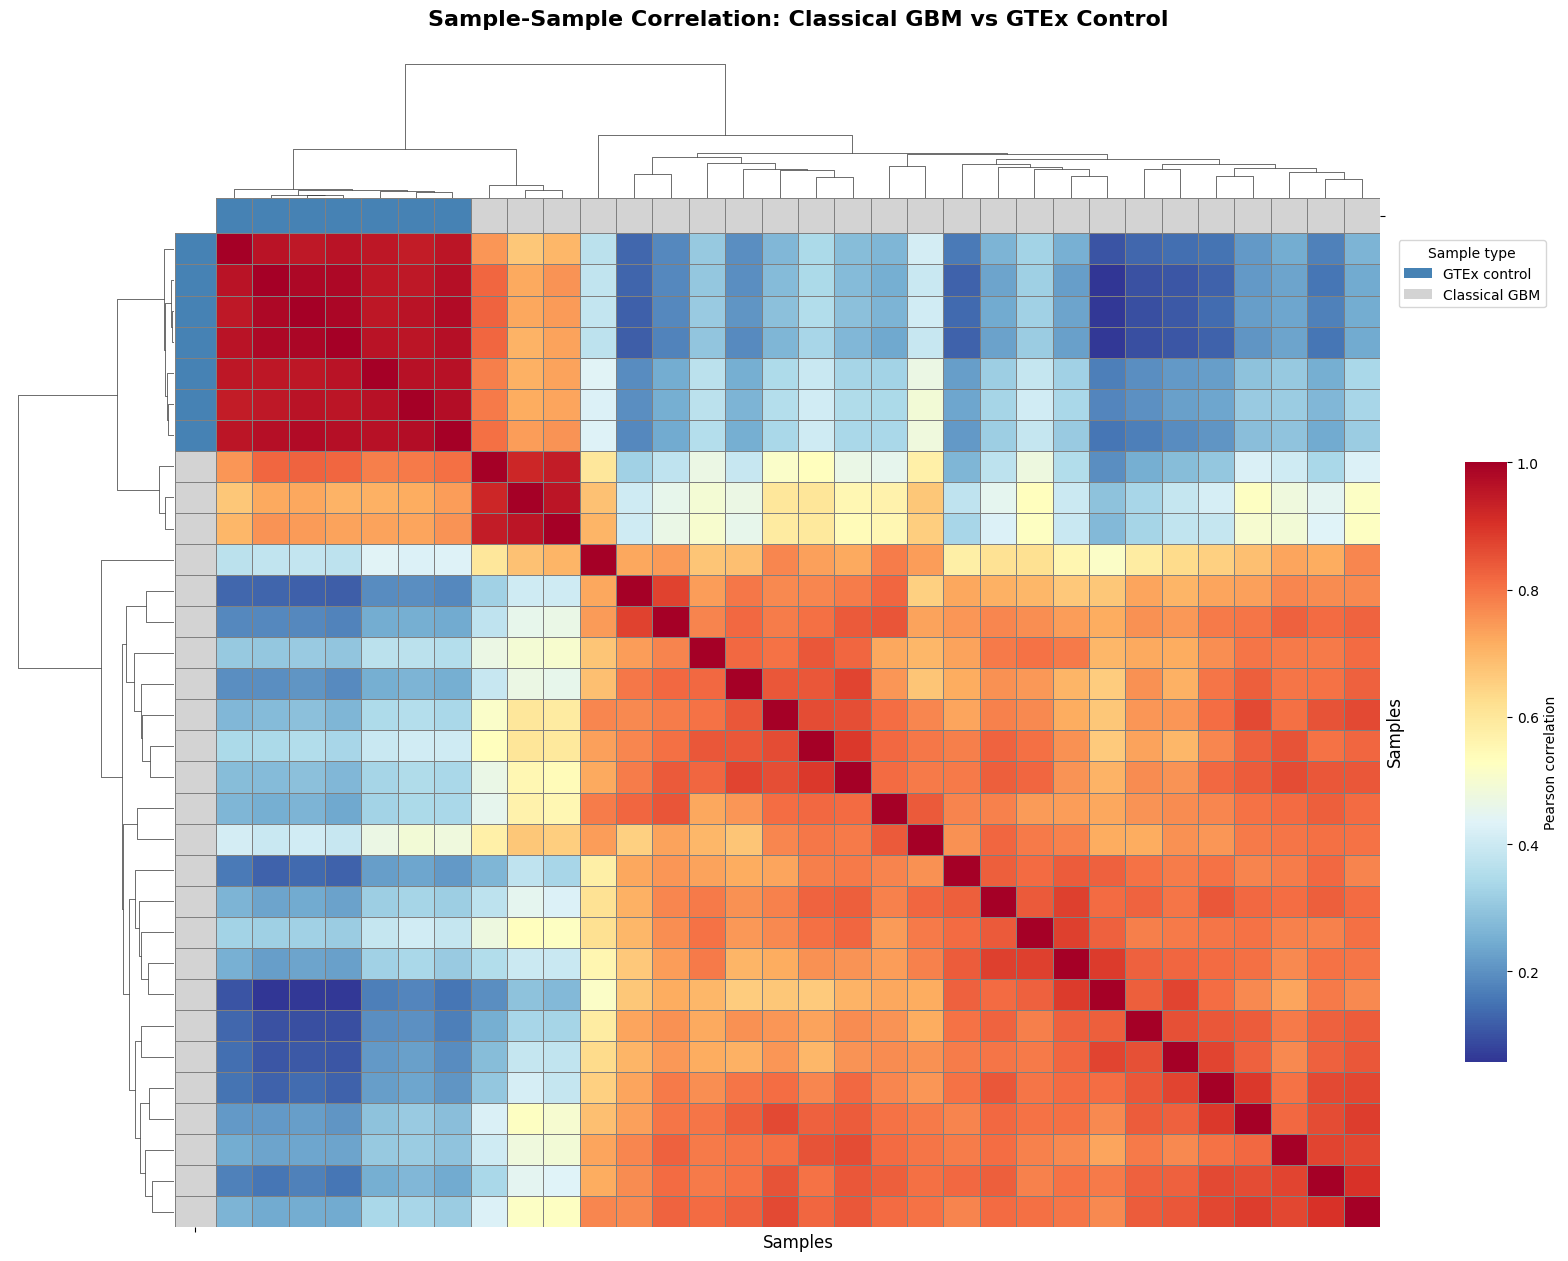

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform


# ============================================================
# LOAD COMBINED RAW COUNTS
# ============================================================

counts = pd.read_csv(
    "../data/processed/CPTAC_GBM_GTEx_7_combined_raw_counts.csv",
    index_col=0
)

counts = counts.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

print("Genes:", counts.shape[0])
print("Samples:", counts.shape[1])


# ============================================================
# LOAD SUBTYPE METADATA
# ============================================================

metadata = pd.read_csv(
    "../data/raw/all_subtypes.v5.1.tsv",
    sep="\t"
)

# First column contains the CPTAC C3L case IDs
metadata = metadata.rename(
    columns={metadata.columns[0]: "sample"}
)

# Select Classical CPTAC cases
classical_cases = metadata.loc[
    metadata["rna_wang_cancer_cell_2017"].astype(str).str.strip().str.lower()
    == "classical",
    "sample"
].astype(str).tolist()

print("Classical cases in metadata:", len(classical_cases))


# ============================================================
# LOAD CPTAC TUMOR MATRIX
# ============================================================

cptac = pd.read_csv(
    "../data/processed/CPTAC_GBM_tumor_raw_counts.csv",
    index_col=0
)

cptac.columns = cptac.columns.astype(str)


# ============================================================
# FIND CLASSICAL SAMPLES IN CPTAC MATRIX
# ============================================================

classical_samples = [
    sample
    for sample in classical_cases
    if sample in cptac.columns
]

print(
    "Classical samples found in CPTAC matrix:",
    len(classical_samples)
)


# ============================================================
# MAP CPTAC CASE IDs TO COMBINED-MATRIX UUIDs
# ============================================================

# The combined matrix uses UUIDs, so the CPTAC tumor matrix
# provides the required case-ID -> UUID relationship.

# If the CPTAC tumor matrix has the same sample columns as the
# combined matrix, use the column positions to identify them.

classical_positions = [
    cptac.columns.get_loc(sample)
    for sample in classical_samples
]

combined_cptac_columns = [
    counts.columns[i]
    for i in classical_positions
]


# ============================================================
# SELECT GTEx CONTROLS
# ============================================================

gtex_samples = [
    sample
    for sample in counts.columns
    if str(sample).upper().startswith("GTEX-")
]


# ============================================================
# SELECT CLASSICAL + GTEx
# ============================================================

selected_samples = (
    combined_cptac_columns
    + gtex_samples
)

counts = counts.loc[
    :,
    selected_samples
]

print(
    "\nClassical samples:",
    len(combined_cptac_columns)
)

print(
    "GTEx controls:",
    len(gtex_samples)
)

print(
    "Total samples:",
    counts.shape[1]
)

# ============================================================
# REMOVE GENES WITH ZERO COUNTS
# ============================================================

counts = counts.loc[
    counts.sum(axis=1) > 0
]


# ============================================================
# LOG2-CPM TRANSFORMATION
# ============================================================

library_sizes = counts.sum(axis=0)

cpm = counts.div(
    library_sizes,
    axis=1
) * 1e6

log_cpm = np.log2(
    cpm + 1
)


# ============================================================
# MOST VARIABLE GENES
# ============================================================

gene_variance = log_cpm.var(axis=1)

n_top_genes = min(
    5000,
    len(gene_variance)
)

top_genes = (
    gene_variance
    .nlargest(n_top_genes)
    .index
)

log_cpm_qc = log_cpm.loc[
    top_genes
]

print(
    "Genes used for correlation:",
    log_cpm_qc.shape[0]
)


# ============================================================
# SAMPLE-SAMPLE PEARSON CORRELATION
# ============================================================

correlation = log_cpm_qc.corr(
    method="pearson"
)


# ============================================================
# HIERARCHICAL CLUSTERING
# ============================================================

distance = 1 - correlation

distance = distance.clip(
    lower=0
)

np.fill_diagonal(
    distance.values,
    0
)

linkage_matrix = linkage(
    squareform(distance.values),
    method="average"
)


# ============================================================
# SAMPLE LABELS
# ============================================================

sample_labels = correlation.columns.tolist()


# ============================================================
# SAMPLE GROUP ANNOTATION
# ============================================================

sample_groups = pd.Series(
    [
        "Control" if str(sample).upper().startswith("GTEX-")
        else "Classical"
        for sample in sample_labels
    ],
    index=sample_labels
)


# ============================================================
# COLOR ANNOTATION
# ============================================================

group_colors = {
    "Classical": "lightgray",
    "Control": "steelblue"
}

col_colors = sample_groups.map(
    group_colors
)


# ============================================================
# HEATMAP
# ============================================================

g = sns.clustermap(
    correlation,
    row_linkage=linkage_matrix,
    col_linkage=linkage_matrix,
    cmap="RdYlBu_r",
    vmin=correlation.min().min(),
    vmax=1,
    figsize=(14, 12),
    linewidths=0.5,
    linecolor="gray",

    # REMOVE SAMPLE NAMES
    xticklabels=False,
    yticklabels=False,

    # CLASSICAL / CONTROL ANNOTATION
    col_colors=col_colors,
    row_colors=col_colors,

    dendrogram_ratio=(0.12, 0.12),

    cbar_kws={
        "label": "Pearson correlation"
    }
)


# ============================================================
# LABELS
# ============================================================

g.ax_heatmap.set_xlabel(
    "Samples",
    fontsize=12
)

g.ax_heatmap.set_ylabel(
    "Samples",
    fontsize=12
)

g.ax_heatmap.set_title(
    "Sample-Sample Correlation: Classical GBM vs GTEx Control",
    pad=150,
    fontsize=16,
    fontweight="bold"
)


# ============================================================
# LEGEND + COLOR BAR
# ============================================================

from matplotlib.patches import Patch

legend_handles = [
    Patch(
        facecolor="steelblue",
        label="GTEx control"
    ),
    Patch(
        facecolor="lightgray",
        label="Classical GBM"
    )
]

g.ax_heatmap.legend(
    handles=legend_handles,
    title="Sample type",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0)
)


# Move correlation color bar underneath the legend
g.ax_cbar.set_position(
    [1.05, 0.15, 0.03, 0.5]
)


plt.show()

Classical samples: 25
['C3L-00365', 'C3L-01040', 'C3L-01048', 'C3L-01061', 'C3L-01154', 'C3L-01155', 'C3L-01156', 'C3L-01327', 'C3L-01887', 'C3L-02642', 'C3L-02707', 'C3L-03266', 'C3L-03387', 'C3L-03390', 'C3L-03681', 'C3L-04084', 'C3N-01196', 'C3N-01334', 'C3N-01368', 'C3N-01517', 'C3N-01852', 'C3N-01857', 'C3N-02782', 'C3N-03184', 'C3N-03188']

GTEx controls: 7


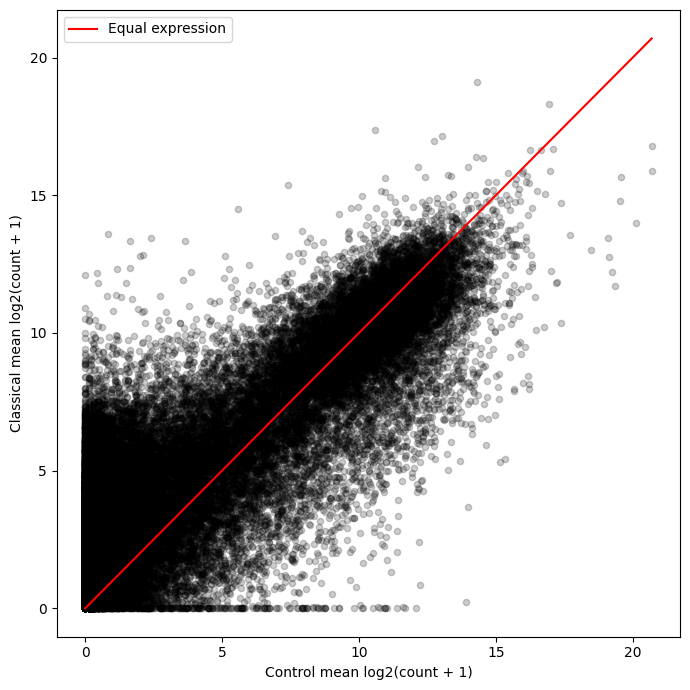

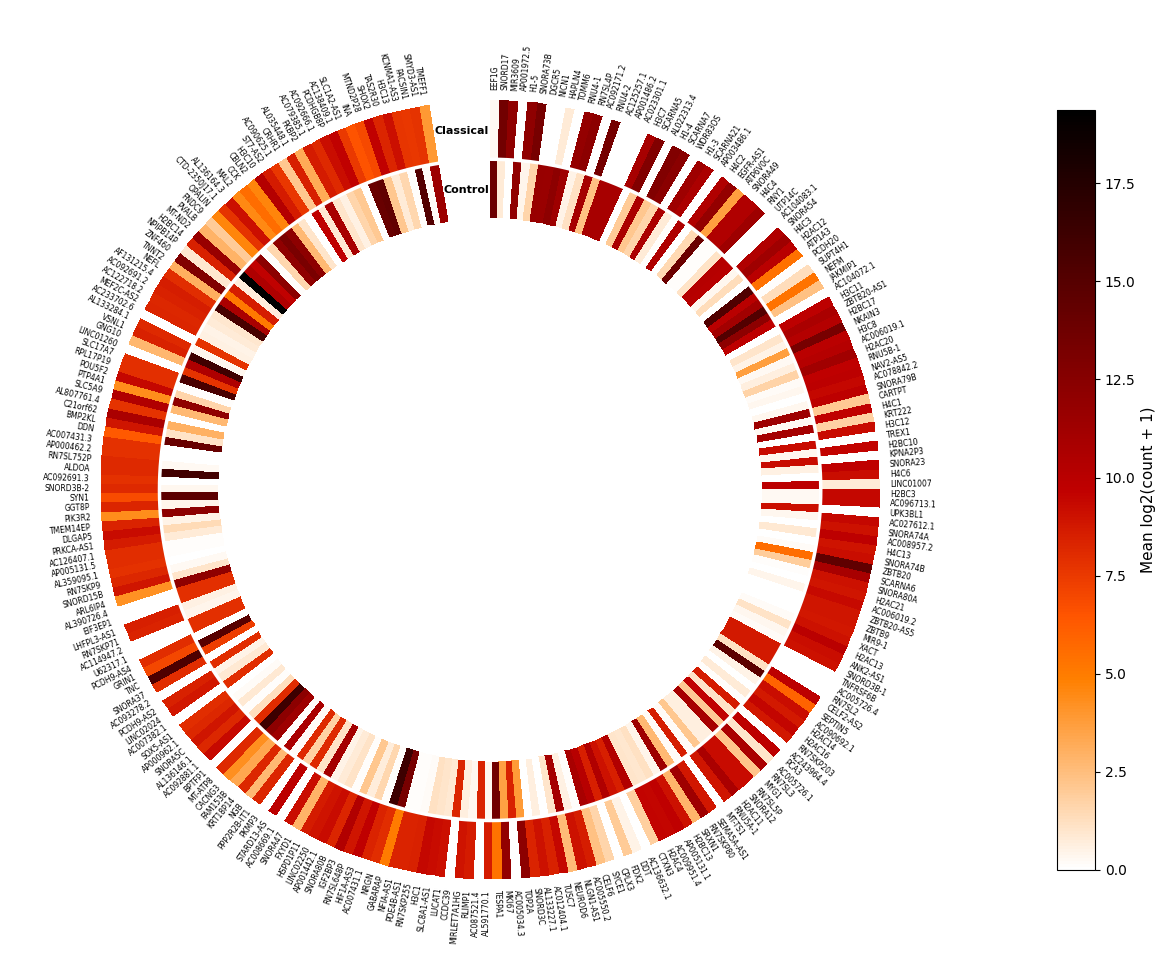

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from pathlib import Path


# ============================================================
# PATHS
# ============================================================

cptac_file = Path(
    "../data/processed/CPTAC_GBM_tumor_raw_counts.csv"
)

gtex_file = Path(
    "../data/processed/GTEx_7_normal_frontal_cortex_raw_counts.csv"
)

subtype_file = Path(
    "../data/raw/all_subtypes.v5.1.tsv"
)


# ============================================================
# LOAD CPTAC
# ============================================================

cptac = pd.read_csv(
    cptac_file,
    index_col=0
)

cptac.index = (
    cptac.index
    .astype(str)
    .str.split(".")
    .str[0]
)


# Remove duplicate genes
cptac = cptac[
    ~cptac.index.duplicated(
        keep="first"
    )
]


# ============================================================
# LOAD GTEx
# ============================================================

gtex = pd.read_csv(
    gtex_file
)

gtex["Name"] = (
    gtex["Name"]
    .astype(str)
    .str.split(".")
    .str[0]
)

gtex = gtex.set_index(
    "Name"
)

if "Description" in gtex.columns:
    gtex = gtex.drop(
        columns="Description"
    )


gtex = gtex[
    ~gtex.index.duplicated(
        keep="first"
    )
]


# ============================================================
# COMMON GENES
# ============================================================

common_genes = (
    cptac.index
    .intersection(gtex.index)
)

cptac = cptac.loc[
    common_genes
]

gtex = gtex.loc[
    common_genes
]


# ============================================================
# LOAD SUBTYPE INFORMATION
# ============================================================

subtypes = pd.read_csv(
    subtype_file,
    sep="\t"
)

subtypes = subtypes.rename(
    columns={
        subtypes.columns[0]: "sample"
    }
)

subtypes["sample"] = (
    subtypes["sample"]
    .astype(str)
    .str.strip()
)


# ============================================================
# SELECT CLASSICAL SAMPLES
# ============================================================

classical_samples = subtypes.loc[
    subtypes["rna_wang_cancer_cell_2017"]
    == "Classical",
    "sample"
].tolist()


# Only retain samples actually present in counts
classical_samples = [
    sample
    for sample in classical_samples
    if sample in cptac.columns
]


print(
    "Classical samples:",
    len(classical_samples)
)

print(
    classical_samples
)


# ============================================================
# SELECT GTEx CONTROLS
# ============================================================

normal_samples = gtex.columns.tolist()


print(
    "\nGTEx controls:",
    len(normal_samples)
)


# ============================================================
# EXPRESSION MATRICES
# ============================================================

gbm_expr = cptac[
    classical_samples
].copy()

normal_expr = gtex[
    normal_samples
].copy()


# ============================================================
# LOG2 TRANSFORMATION
# ============================================================

# Raw RNA-seq counts are highly right-skewed.
# log2(count + 1) makes the expression values more suitable
# for visualization.

gbm_expr = np.log2(
    gbm_expr + 1
)

normal_expr = np.log2(
    normal_expr + 1
)


# ============================================================
# MEAN EXPRESSION
# ============================================================

avg_norm = normal_expr.mean(
    axis=1
)

avg_clas = gbm_expr.mean(
    axis=1
)


plot_df = pd.DataFrame({
    "Control": avg_norm,
    "Classical": avg_clas
}).dropna()

# ============================================================
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    plot_df["Control"],
    plot_df["Classical"],
    color="black",
    alpha=0.2,
    s=20
)

# x = y reference line
min_val = min(
    plot_df["Control"].min(),
    plot_df["Classical"].min()
)

max_val = max(
    plot_df["Control"].max(),
    plot_df["Classical"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linewidth=1.5,
    label = 'Equal expression'
)

plt.legend()

plt.xlabel(
    "Control mean log2(count + 1)"
)

plt.ylabel(
    "Classical mean log2(count + 1)"
)

plt.title(
    "Classical GBM vs Control Expression"
)

plt.tight_layout()

plt.show()

# ============================================================
# SELECT GENES
# ============================================================

n_genes = 250

plot_df["abs_diff"] = (
    plot_df["Classical"]
    - plot_df["Control"]
).abs()


plot_df = (
    plot_df
    .sort_values(
        "abs_diff",
        ascending=False
    )
    .head(n_genes)
    .drop(
        columns="abs_diff"
    )
)


# ============================================================
# GENE NAMES
# ============================================================

# At this point the index is still Ensembl IDs.
#
# If you have already created a gene_mapping dataframe
# containing:
#
#     gene_id
#     gene_name
#
# use it here.

original_cptac = pd.read_csv('../data/raw/CPTAC_GBM/0a14b390-558e-418a-83f8-148f459f2855/fdaad4b3-332b-4187-8e0d-c2f639add45c.rna_seq.augmented_star_gene_counts.tsv',skiprows=1,sep="\t")

gene_mapping = original_cptac[
    [
        "gene_id",
        "gene_name"
    ]
].copy()

gene_mapping["gene_id"] = (
    gene_mapping["gene_id"]
    .astype(str)
    .str.split(".")
    .str[0]
)

gene_mapping["gene_name"] = (
    gene_mapping["gene_name"]
    .astype(str)
    .str.strip()
)

gene_mapping = gene_mapping.drop_duplicates(
    subset="gene_id"
)


# Map Ensembl -> gene name
gene_name_dict = dict(
    zip(
        gene_mapping["gene_id"],
        gene_mapping["gene_name"]
    )
)


plot_df["gene_name"] = [
    gene_name_dict.get(
        gene,
        gene
    )
    for gene in plot_df.index
]


# ============================================================
# MATRIX
# ============================================================

# Row 0 = Control
# Row 1 = Classical

Z = plot_df[
    [
        "Control",
        "Classical"
    ]
].T.to_numpy()

n_rings, n_cols = Z.shape

gene_names = (
    plot_df["gene_name"]
    .astype(str)
    .tolist()
)


# ============================================================
# CIRCULAR GEOMETRY
# ============================================================

gap_ratio = 0.025

full_circle = 2 * np.pi

theta_start = 0

theta_end = (
    full_circle *
    (1 - gap_ratio)
)

theta_edges = np.linspace(
    theta_start,
    theta_end,
    n_cols + 1
)


# ============================================================
# RING SIZE
# ============================================================

inner_radius = 3.0

ring_width = 0.65

middle_radius = (
    inner_radius +
    ring_width
)

outer_radius = (
    middle_radius +
    ring_width
)


r = np.array([
    inner_radius,
    middle_radius,
    outer_radius
])


T, R = np.meshgrid(
    theta_edges,
    r
)


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 14),
    subplot_kw={
        "projection": "polar"
    }
)

ax.set_theta_direction(-1)

ax.set_theta_offset(
    np.pi / 2
)


# ============================================================
# EXPRESSION COLOR SCALE
# ============================================================

norm = Normalize(
    vmin=np.nanmin(Z),
    vmax=np.nanmax(Z)
)

cmap = plt.cm.gist_heat_r


mesh = ax.pcolormesh(
    T,
    R,
    Z,
    cmap=cmap,
    norm=norm,
    shading="flat"
)


# ============================================================
# CONTROL / CLASSICAL SEPARATOR
# ============================================================

theta_line = np.linspace(
    theta_start,
    theta_end,
    1000
)

ax.plot(
    theta_line,
    np.full_like(
        theta_line,
        middle_radius
    ),
    color="white",
    linewidth=2.5,
    zorder=10
)


# ============================================================
# AXIS LIMITS
# ============================================================

label_radius = (
    outer_radius +
    0.55
)

ax.set_ylim(
    0,
    label_radius + 0.45
)


# ============================================================
# REMOVE POLAR AXIS
# ============================================================

ax.set_xticks([])

ax.set_yticks([])

ax.grid(False)

ax.spines[
    "polar"
].set_visible(False)


# ============================================================
# SAMPLE LABELS
# ============================================================

gap_angle = (
    theta_end +
    full_circle
) / 2


# Classical

ax.text(
    gap_angle,
    middle_radius +
    ring_width * 0.5,
    "Classical",
    ha="center",
    va="center",
    fontsize=8,
    fontweight="bold"
)


# Control

ax.text(
    gap_angle,
    inner_radius +
    ring_width * 0.5,
    "Control",
    ha="center",
    va="center",
    fontsize=8,
    fontweight="bold"
)


# ============================================================
# GENE LABELS
# ============================================================

label_radius = (
    outer_radius +
    0.12
)


for i, gene in enumerate(
    gene_names
):

    angle = (
        theta_edges[i] +
        theta_edges[i + 1]
    ) / 2


    visual_angle = (
        90 -
        np.degrees(angle)
    )

    visual_angle = (
        visual_angle %
        360
    )


    rotation = visual_angle


    if (
        90 <
        visual_angle <
        270
    ):

        rotation += 180

        ha = "right"

    else:

        ha = "left"


    ax.text(
        angle,
        label_radius,
        gene,
        rotation=rotation,
        rotation_mode="anchor",
        ha=ha,
        va="center",
        fontsize=5.5,
        clip_on=False
    )


# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    mesh,
    ax=ax,
    fraction=0.035,
    pad=0.08,
    shrink=0.75
)

cbar.set_label(
    "Mean log2(count + 1)",
    fontsize=11
)


# ============================================================
# TITLE
# ============================================================

ax.set_title(
    "Classical GBM vs Control RNA Expression",
    fontsize=15,
    fontweight="bold",
    pad=30
)


# ============================================================
# SAVE
# ============================================================

output_path = (
    "../data/interim/network_stat/"
    "classical_normal_vs_classical_circular_heatmap.svg"
)

plt.savefig(
    output_path,
    format="svg",
    bbox_inches="tight"
)


plt.show()

CPTAC SUBTYPE MATCHING
CPTAC samples: 99
Metadata samples: 99
Matched samples: 99

Subtype counts:
subtype
Mesenchymal    39
Proneural      29
Classical      25
IDH mutant      6
Name: count, dtype: int64

COUNT MATRICES
Classical: (55617, 25)
Proneural: (55617, 29)
Mesenchymal: (55617, 39)
GTEx: (55617, 7)


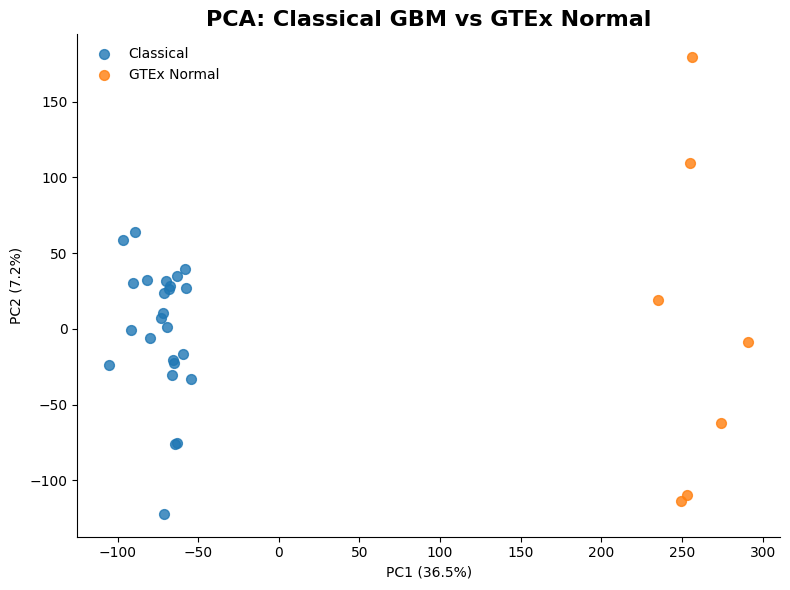

In [1]:
# ============================================================
# GET CPTAC SUBTYPE COUNT MATRICES + GTEx COUNTS
# NO MANUAL SAMPLE-ID INPUT
# ============================================================

import pandas as pd


# ============================================================
# 1. LOAD CPTAC COUNTS
# ============================================================

cptac = pd.read_csv(
    "../data/processed/CPTAC_GBM_tumor_raw_counts.csv"
)

cptac["gene_id"] = (
    cptac["gene_id"]
    .astype(str)
    .str.split(".")
    .str[0]
)

cptac = cptac.set_index("gene_id")

cptac = cptac[
    ~cptac.index.duplicated(keep="first")
]


# ============================================================
# 2. LOAD GTEx COUNTS
# ============================================================

gtex = pd.read_csv(
    "../data/processed/GTEx_7_normal_frontal_cortex_raw_counts.csv"
)

gtex["Name"] = (
    gtex["Name"]
    .astype(str)
    .str.split(".")
    .str[0]
)

gtex = gtex.set_index("Name")

if "Description" in gtex.columns:
    gtex = gtex.drop(columns="Description")

gtex = gtex[
    ~gtex.index.duplicated(keep="first")
]


# ============================================================
# 3. FIND COMMON GENES
# ============================================================

common_genes = (
    cptac.index
    .intersection(gtex.index)
)

cptac = cptac.loc[
    common_genes
].copy()

gtex = gtex.loc[
    common_genes
].copy()


# ============================================================
# 4. LOAD SUBTYPE METADATA
# ============================================================

subtypes = pd.read_csv(
    "../data/raw/all_subtypes.v5.1.tsv",
    sep="\t"
)

# First column contains the CPTAC case IDs
subtypes = subtypes.rename(
    columns={
        subtypes.columns[0]: "sample"
    }
)

subtypes["sample"] = (
    subtypes["sample"]
    .astype(str)
    .str.strip()
)


# ============================================================
# 5. GET SUBTYPE INFORMATION
# ============================================================

subtype_table = subtypes[
    [
        "sample",
        "rna_wang_cancer_cell_2017"
    ]
].copy()

subtype_table = subtype_table.rename(
    columns={
        "rna_wang_cancer_cell_2017": "subtype"
    }
)

# Remove missing subtype assignments
subtype_table = subtype_table.dropna(
    subset=["subtype"]
)


# ============================================================
# 6. MATCH METADATA TO CPTAC COUNTS
# ============================================================

matched = subtype_table[
    subtype_table["sample"].isin(
        cptac.columns
    )
].copy()

print("=" * 70)
print("CPTAC SUBTYPE MATCHING")
print("=" * 70)

print(
    "CPTAC samples:",
    len(cptac.columns)
)

print(
    "Metadata samples:",
    len(subtype_table)
)

print(
    "Matched samples:",
    len(matched)
)

print("\nSubtype counts:")
print(
    matched["subtype"].value_counts()
)


# ============================================================
# 7. EXTRACT SUBTYPE SAMPLE IDs AUTOMATICALLY
# ============================================================

classical_samples = matched.loc[
    matched["subtype"].eq("Classical"),
    "sample"
].tolist()

proneural_samples = matched.loc[
    matched["subtype"].eq("Proneural"),
    "sample"
].tolist()

mesenchymal_samples = matched.loc[
    matched["subtype"].eq("Mesenchymal"),
    "sample"
].tolist()


# ============================================================
# 8. EXTRACT COUNT MATRICES
# ============================================================

classical_counts = cptac[
    classical_samples
].copy()

proneural_counts = cptac[
    proneural_samples
].copy()

mesenchymal_counts = cptac[
    mesenchymal_samples
].copy()


# ============================================================
# 9. GET GTEx SAMPLES AUTOMATICALLY
# ============================================================

gtex_samples = [
    sample
    for sample in gtex.columns
    if str(sample).startswith("GTEX-")
]

gtex_counts = gtex[
    gtex_samples
].copy()


# ============================================================
# 10. NUMERIC COUNTS
# ============================================================

classical_counts = classical_counts.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

proneural_counts = proneural_counts.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

mesenchymal_counts = mesenchymal_counts.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)

gtex_counts = gtex_counts.apply(
    pd.to_numeric,
    errors="coerce"
).fillna(0)


# ============================================================
# 11. SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("COUNT MATRICES")
print("=" * 70)

print(
    "Classical:",
    classical_counts.shape
)

print(
    "Proneural:",
    proneural_counts.shape
)

print(
    "Mesenchymal:",
    mesenchymal_counts.shape
)

print(
    "GTEx:",
    gtex_counts.shape
)

import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)

pca_df_classical, pca_classical = diff.pca_plot(
    case_expr=classical_counts,
    control_expr=gtex_counts,
    case_label="Classical",
    control_label="GTEx Normal",
    title="PCA: Classical GBM vs GTEx Normal"
)




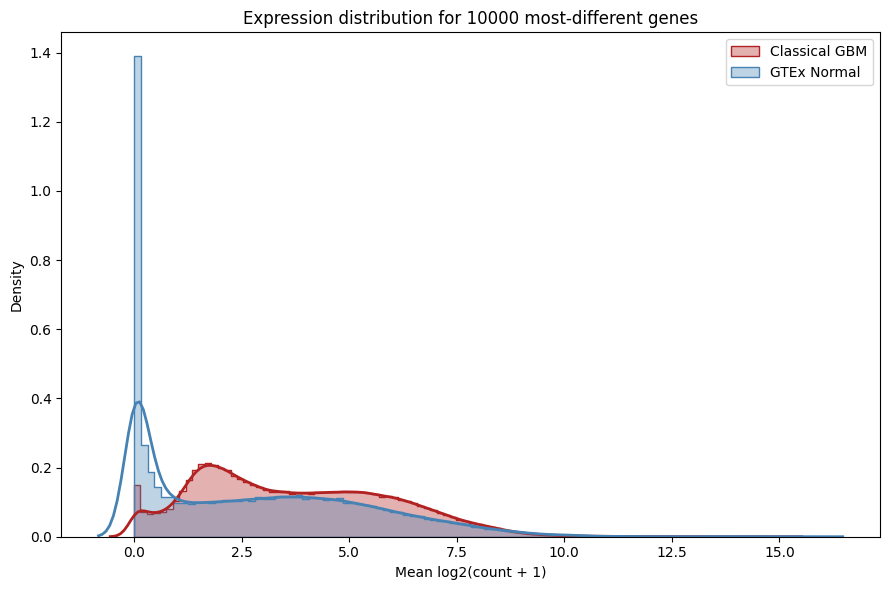

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# OVERLAID EXPRESSION DISTRIBUTIONS FOR MOST DIFFERENT GENES
# ============================================================

# Normalize counts within each sample, then transform expression
# values for a comparable visualization scale.
classical_library_sizes = classical_counts.sum(axis=0)
gtex_library_sizes = gtex_counts.sum(axis=0)

classical_log_cpm = np.log2(
    classical_counts.div(classical_library_sizes, axis=1) * 1e6 + 1
)

gtex_log_cpm = np.log2(
    gtex_counts.div(gtex_library_sizes, axis=1) * 1e6 + 1
)

# Select genes with the largest absolute difference in mean expression.
mean_expression_difference = (
    classical_log_cpm.mean(axis=1)
    - gtex_log_cpm.mean(axis=1)
).abs()

n_top = 10000

top_genes = mean_expression_difference.nlargest(n_top).index

classical_expression = classical_log_cpm.loc[
    top_genes
].to_numpy().ravel()

gtex_expression = gtex_log_cpm.loc[
    top_genes
].to_numpy().ravel()

plt.figure(figsize=(9, 6))

sns.histplot(
    classical_expression,
    bins=100,
    stat="density",
    color="firebrick",
    alpha=0.35,
    element="step",
    fill=True,
    label="Classical GBM"
)

sns.histplot(
    gtex_expression,
    bins=100,
    stat="density",
    color="steelblue",
    alpha=0.35,
    element="step",
    fill=True,
    label="GTEx Normal"
)

sns.kdeplot(
    classical_expression,
    color="firebrick",
    linewidth=2,
    warn_singular=False
)

sns.kdeplot(
    gtex_expression,
    color="steelblue",
    linewidth=2,
    warn_singular=False
)

plt.xlabel("Mean log2(count + 1)")
plt.ylabel("Density")
plt.title(f"Expression distribution for {n_top} most-different genes")
plt.legend()
plt.tight_layout()
plt.show()